In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# List what's in your drive root
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Certifications', 'Interview.gdoc', 'Needed.gsheet', 'Resume', 'Company Applied.gsheet', 'Companies.gsheet', 'lung_project']


In [ ]:
# Replace 'lung_cancer_dataset' with your actual folder name
dataset_path = '/content/drive/MyDrive/lung_project/Dataset'
print(os.listdir(dataset_path))

['test', 'train', 'valid']


In [ ]:
# Should show: ['train', 'test', 'valid']  or similar
print(os.listdir(dataset_path))

# Check train subfolders (these are your class names)
train_path = os.path.join(dataset_path, 'train')
print(os.listdir(train_path))

['test', 'train', 'valid']
['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'normal', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']


In [ ]:
import os

def count_images(base_path):
    for split in ['train', 'test', 'valid']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            print(f"{split}: NOT FOUND")
            continue
        print(f"\n{split}:")
        total = 0
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                count = len(os.listdir(cls_path))
                print(f"  {cls}: {count} images")
                total += count
        print(f"  TOTAL: {total}")

count_images(dataset_path)


train:
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 images
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 images
  normal: 148 images
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 images
  TOTAL: 613

test:
  adenocarcinoma: 120 images
  large.cell.carcinoma: 51 images
  normal: 54 images
  squamous.cell.carcinoma: 90 images
  TOTAL: 315

valid:
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 23 images
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 21 images
  normal: 13 images
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 15 images
  TOTAL: 72


In [ ]:
!pip install tensorflow pillow numpy scikit-learn matplotlib

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.

Class indices: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
Train: 613  |  Val: 72  |  Test: 315
Class weights: {0: np.float64(0.786), 1: np.float64(1.333), 2: np.float64(1.035), 3: np.float64(0.989)}

Total parameters: 22,085,548

PHASE 1 — Training new top layers (base frozen)
Epoch 1/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.3434 - loss: 1.7210
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /content/drive/MyDrive/lung_project/model_output/phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lung_project/model_output/phase1_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step 

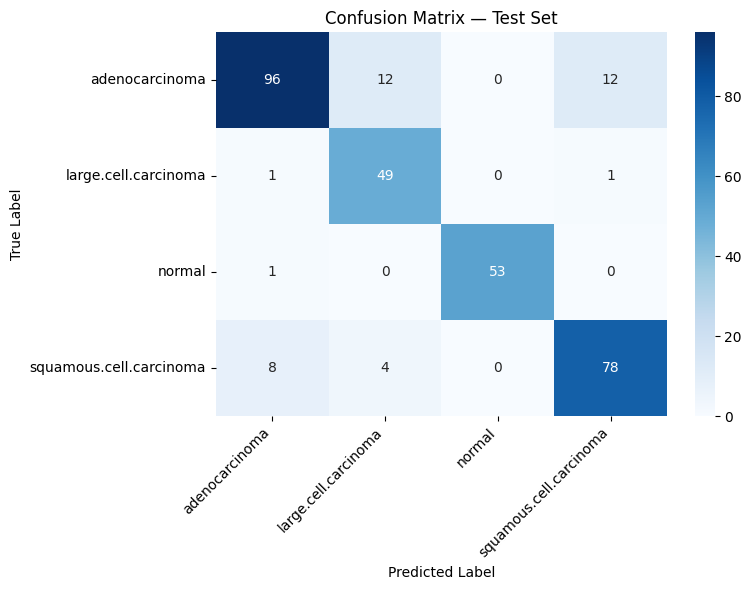

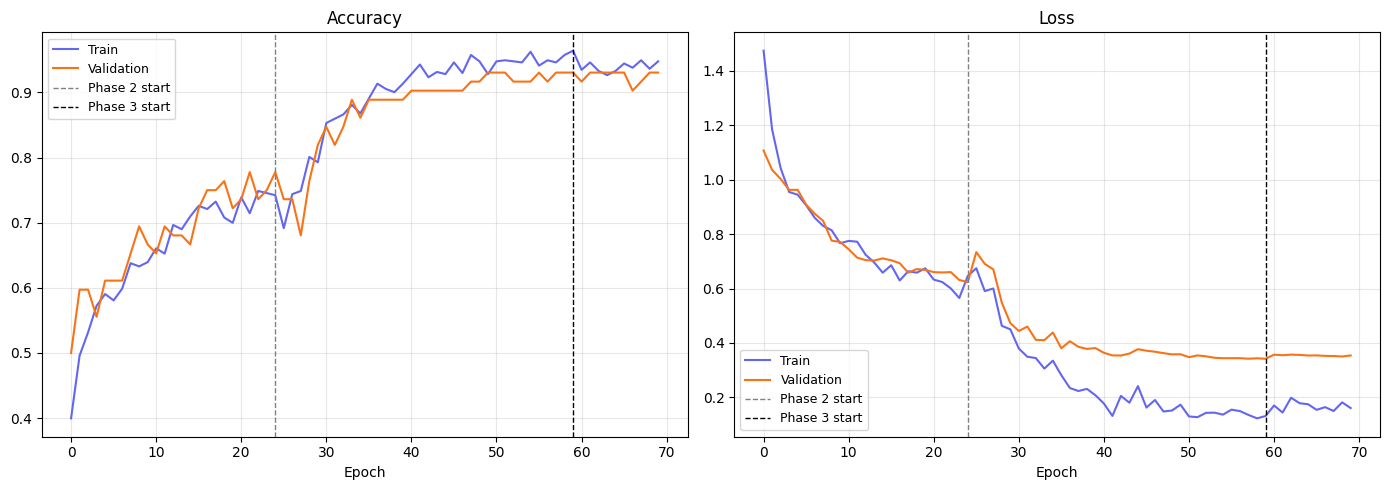


Model saved  →  /content/drive/MyDrive/lung_project/model_output/lung_cancer_model.h5
Classes saved → /content/drive/MyDrive/lung_project/model_output/class_indices.json

Class map: {'0': 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', '1': 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', '2': 'normal', '3': 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'}

Files in output folder:
  phase1_best.keras  (98.6 MB)
  phase2_best.keras  (183.1 MB)
  phase3_best.keras  (183.1 MB)
  confusion_matrix.png  (0.1 MB)
  training_curves.png  (0.1 MB)
  lung_cancer_model.h5  (183.1 MB)
  class_indices.json  (0.0 MB)


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                     Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (ReduceLROnPlateau, EarlyStopping,
                                        ModelCheckpoint)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# ── Paths ─────────────────────────────────────────────────────────────────────
# Change these to match your actual paths
TRAIN_DIR = '/content/drive/MyDrive/lung_project/Dataset/train'
VAL_DIR   = '/content/drive/MyDrive/lung_project/Dataset/valid'
TEST_DIR  = '/content/drive/MyDrive/lung_project/Dataset/test'

SAVE_DIR  = '/content/drive/MyDrive/lung_project/model_output'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
IMAGE_SIZE    = (299, 299)
BATCH_SIZE    = 16
NUM_CLASSES   = 4

# Phase 1 — train only the new top layers (base frozen)
EPOCHS_P1     = 25

# Phase 2 — unfreeze last 40 Xception layers (deeper fine-tune)
EPOCHS_P2     = 40
UNFREEZE_LAST = 40

# Phase 3 — unfreeze entire model with very tiny LR
EPOCHS_P3     = 20

# ── Stronger augmentation ─────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.20,
    height_shift_range=0.20,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.75, 1.25],   # simulate different scan exposures
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_gen.class_indices)
print(f"Train: {train_gen.samples}  |  Val: {val_gen.samples}  |  Test: {test_gen.samples}")

# ── Class weights ─────────────────────────────────────────────────────────────
labels = train_gen.classes
cw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(cw))
print("Class weights:", {k: round(v, 3) for k, v in class_weight_dict.items()})

# ── Build model ───────────────────────────────────────────────────────────────
def build_model():
    base = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMAGE_SIZE, 3)
    )
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs=base.input, outputs=output), base

model, base_model = build_model()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — Train only new top layers, base frozen
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("PHASE 1 — Training new top layers (base frozen)")
print("="*55)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_p1 = [
    ReduceLROnPlateau(monitor='val_accuracy', patience=4,
                      factor=0.5, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(SAVE_DIR, 'phase1_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

h1 = model.fit(
    train_gen,
    epochs=EPOCHS_P1,
    validation_data=val_gen,
    callbacks=cb_p1,
    class_weight=class_weight_dict
)
print(f"Phase 1 best val accuracy: {max(h1.history['val_accuracy'])*100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — Unfreeze last 40 Xception layers, fine-tune
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"PHASE 2 — Fine-tuning last {UNFREEZE_LAST} Xception layers")
print("="*55)

base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_LAST]:
    layer.trainable = False

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers: {trainable}")

model.compile(
    optimizer=Adam(learning_rate=1e-4),   # slightly higher than before
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_p2 = [
    ReduceLROnPlateau(monitor='val_accuracy', patience=4,
                      factor=0.3, min_lr=1e-8, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(SAVE_DIR, 'phase2_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

h2 = model.fit(
    train_gen,
    epochs=EPOCHS_P2,
    validation_data=val_gen,
    callbacks=cb_p2,
    class_weight=class_weight_dict
)
print(f"Phase 2 best val accuracy: {max(h2.history['val_accuracy'])*100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
# PHASE 3 — Unfreeze entire model, very small LR
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("PHASE 3 — Full model fine-tune (tiny LR)")
print("="*55)

base_model.trainable = True   # unfreeze all

model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_p3 = [
    ReduceLROnPlateau(monitor='val_accuracy', patience=3,
                      factor=0.5, min_lr=1e-9, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(SAVE_DIR, 'phase3_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

h3 = model.fit(
    train_gen,
    epochs=EPOCHS_P3,
    validation_data=val_gen,
    callbacks=cb_p3,
    class_weight=class_weight_dict
)
print(f"Phase 3 best val accuracy: {max(h3.history['val_accuracy'])*100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
# FINAL EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL TEST SET EVALUATION")
print("="*55)

test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Per-class report
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# TRAINING CURVES
# ─────────────────────────────────────────────────────────────────────────────
acc   = h1.history['accuracy']     + h2.history['accuracy']     + h3.history['accuracy']
vacc  = h1.history['val_accuracy'] + h2.history['val_accuracy'] + h3.history['val_accuracy']
loss  = h1.history['loss']         + h2.history['loss']         + h3.history['loss']
vloss = h1.history['val_loss']     + h2.history['val_loss']     + h3.history['val_loss']

p1_end = len(h1.history['accuracy'])
p2_end = p1_end + len(h2.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_vals, val_vals, title in [
    (axes[0], acc,  vacc, 'Accuracy'),
    (axes[1], loss, vloss, 'Loss')
]:
    ax.plot(train_vals, label='Train',      color='#6366f1')
    ax.plot(val_vals,   label='Validation', color='#f97316')
    ax.axvline(p1_end - 1, color='gray',  linestyle='--', linewidth=1, label='Phase 2 start')
    ax.axvline(p2_end - 1, color='black', linestyle='--', linewidth=1, label='Phase 3 start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=120)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SAVE FINAL MODEL + CLASS MAP
# ─────────────────────────────────────────────────────────────────────────────
import json

model_path   = os.path.join(SAVE_DIR, 'lung_cancer_model.h5')
classes_path = os.path.join(SAVE_DIR, 'class_indices.json')

model.save(model_path)

idx_to_class = {str(v): k for k, v in train_gen.class_indices.items()}
with open(classes_path, 'w') as f:
    json.dump(idx_to_class, f, indent=2)

print(f"\nModel saved  →  {model_path}")
print(f"Classes saved → {classes_path}")
print("\nClass map:", idx_to_class)

print("\nFiles in output folder:")
for fname in os.listdir(SAVE_DIR):
    size_mb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1e6
    print(f"  {fname}  ({size_mb:.1f} MB)")


In [ ]:
from google.colab import files
import os

SAVE_DIR = '/content/drive/MyDrive/lung_project/model_output'

# Verify files exist
for f in ['lung_cancer_model.h5', 'class_indices.json']:
    path = os.path.join(SAVE_DIR, f)
    size = os.path.getsize(path) / 1e6
    print(f"{f}  →  {size:.1f} MB")

# Download both
files.download(os.path.join(SAVE_DIR, 'lung_cancer_model.h5'))
files.download(os.path.join(SAVE_DIR, 'class_indices.json'))

lung_cancer_model.h5  →  183.1 MB
class_indices.json  →  0.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>